<a href="https://colab.research.google.com/github/sanjana45-cloud/fraudshield/blob/main/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import warnings

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("OnlineRetail.csv", encoding='latin1')

In [5]:
df = df.dropna()

In [6]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
print(f"Clean dataset: {df.shape[0]:,} rows")

Clean dataset: 23,867 rows


In [7]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")

Snapshot date: 2010-12-18


In [8]:
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate',  lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',    'nunique'),   # unique invoices = purchase occasions
    Monetary  = ('TotalPrice',   'sum')
).reset_index()

In [9]:
print("\nRFM Summary Statistics:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))


RFM Summary Statistics:
       Recency  Frequency  Monetary
count   837.00     837.00    837.00
mean      8.32       1.52    619.84
std       5.12       1.82   1450.57
min       1.00       1.00     12.45
25%       4.00       1.00    194.85
50%       9.00       1.00    318.85
75%      12.00       2.00    556.50
max      17.00      34.00  27834.61


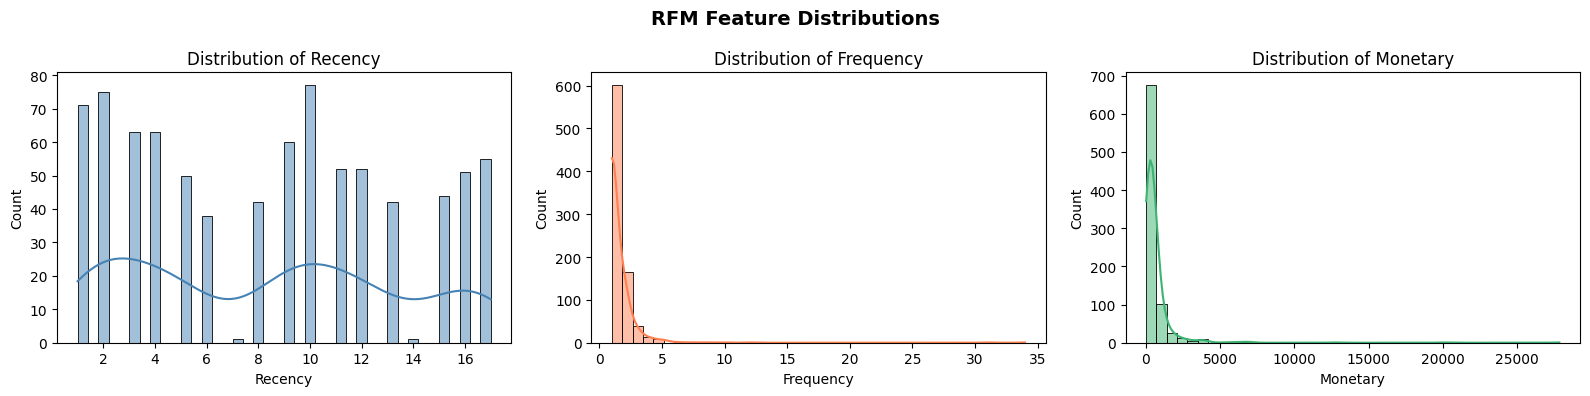

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, color in zip(axes,
                           ['Recency', 'Frequency', 'Monetary'],
                           ['steelblue', 'coral', 'mediumseagreen']):
    sns.histplot(rfm[col], bins=40, ax=ax, color=color, kde=True)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
plt.suptitle('RFM Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_distributions.png', dpi=150)
plt.show()

In [11]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

In [12]:
inertias      = []
silhouettes   = []
K_range       = list(range(2, 11))


In [13]:
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, labels))


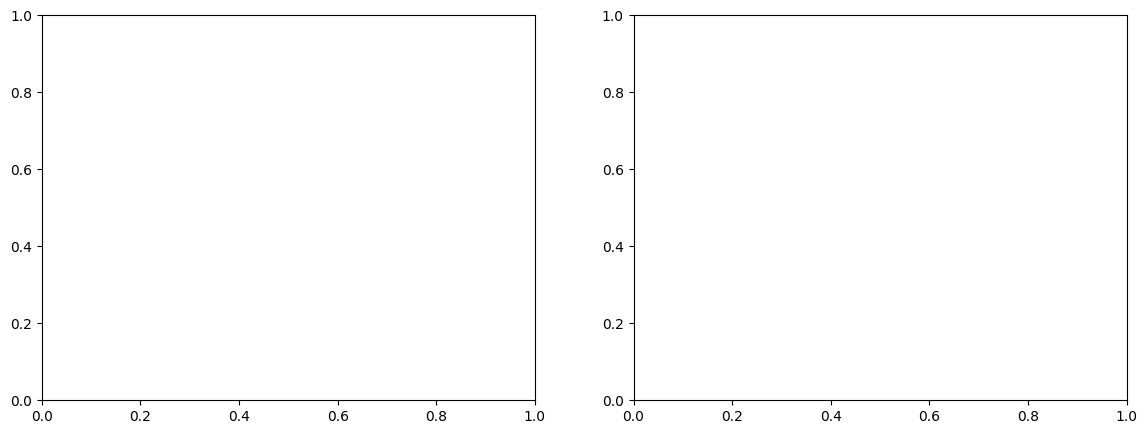

In [14]:
 fig, axes = plt.subplots(1, 2, figsize=(14, 5))

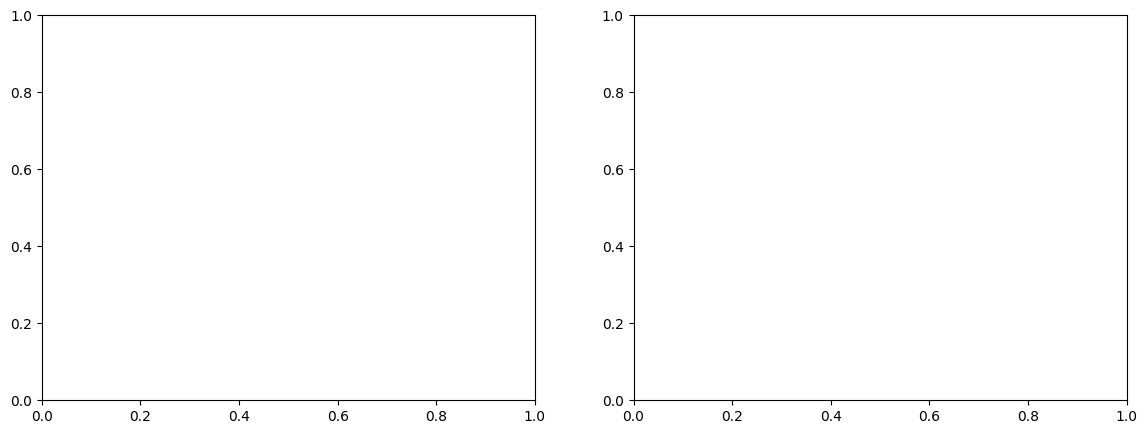

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [16]:
axes[0].plot(K_range, inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method — Inertia vs K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(x=4, color='red', linestyle='--', label='Chosen K=4')
axes[0].legend()


In [17]:
axes[1].plot(K_range, silhouettes, marker='s', color='coral')
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(x=4, color='red', linestyle='--', label='Chosen K=4')
axes[1].legend()


In [18]:
plt.suptitle('Choosing Optimal Number of Clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150)
plt.show()

<Figure size 640x480 with 0 Axes>

In [19]:
best_k = K_range[silhouettes.index(max(silhouettes))]
print(f"\nBest K by Silhouette: {best_k}")
print(f"Silhouette Score at K={best_k}: {max(silhouettes):.4f}")



Best K by Silhouette: 2
Silhouette Score at K=2: 0.8708


In [20]:
FINAL_K = 4
kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [21]:
print(f"\nSilhouette Score (K={FINAL_K}): "
      f"{silhouette_score(rfm_scaled, rfm['Cluster']):.4f}")


Silhouette Score (K=4): 0.5221


In [22]:
cluster_profile = rfm.groupby('Cluster').agg(
    Count     = ('CustomerID', 'count'),
    Recency   = ('Recency',    'mean'),
    Frequency = ('Frequency',  'mean'),
    Monetary  = ('Monetary',   'mean')
).round(2)

In [23]:
print(" Cluster Profiles:")
print(cluster_profile)

 Cluster Profiles:
         Count  Recency  Frequency  Monetary
Cluster                                     
0          368     3.33       1.73    729.40
1          464    12.30       1.18    388.92
2            2     8.50      32.50   4755.23
3            3     4.67       7.00  20139.46


In [24]:
def label_cluster(row):
    if row['Recency'] < 30 and row['Frequency'] > 5 and row['Monetary'] > 1000:
        return 'Champions'
    elif row['Recency'] < 60 and row['Frequency'] >= 3:
        return 'Loyal Customers'
    elif row['Recency'] > 150:
        return 'Lost Customers'
    else:
        return 'At-Risk / Occasional'

In [25]:
cluster_profile['Segment_Label'] = cluster_profile.apply(label_cluster, axis=1)
print("\n🏷 Segment Labels:")
print(cluster_profile[['Count', 'Recency', 'Frequency', 'Monetary', 'Segment_Label']])



🏷 Segment Labels:
         Count  Recency  Frequency  Monetary         Segment_Label
Cluster                                                           
0          368     3.33       1.73    729.40  At-Risk / Occasional
1          464    12.30       1.18    388.92  At-Risk / Occasional
2            2     8.50      32.50   4755.23             Champions
3            3     4.67       7.00  20139.46             Champions


In [26]:
label_map = cluster_profile['Segment_Label'].to_dict()
rfm['Segment'] = rfm['Cluster'].map(label_map)

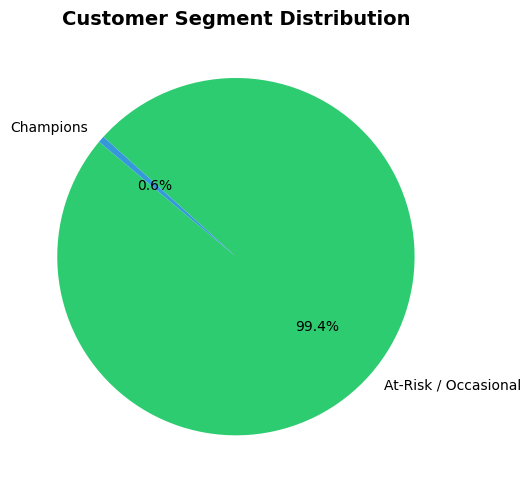

In [27]:
plt.figure(figsize=(8, 5))
seg_counts = rfm['Segment'].value_counts()
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
plt.pie(seg_counts.values, labels=seg_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=140)
plt.title('Customer Segment Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('segment_distribution.png', dpi=150)
plt.show()

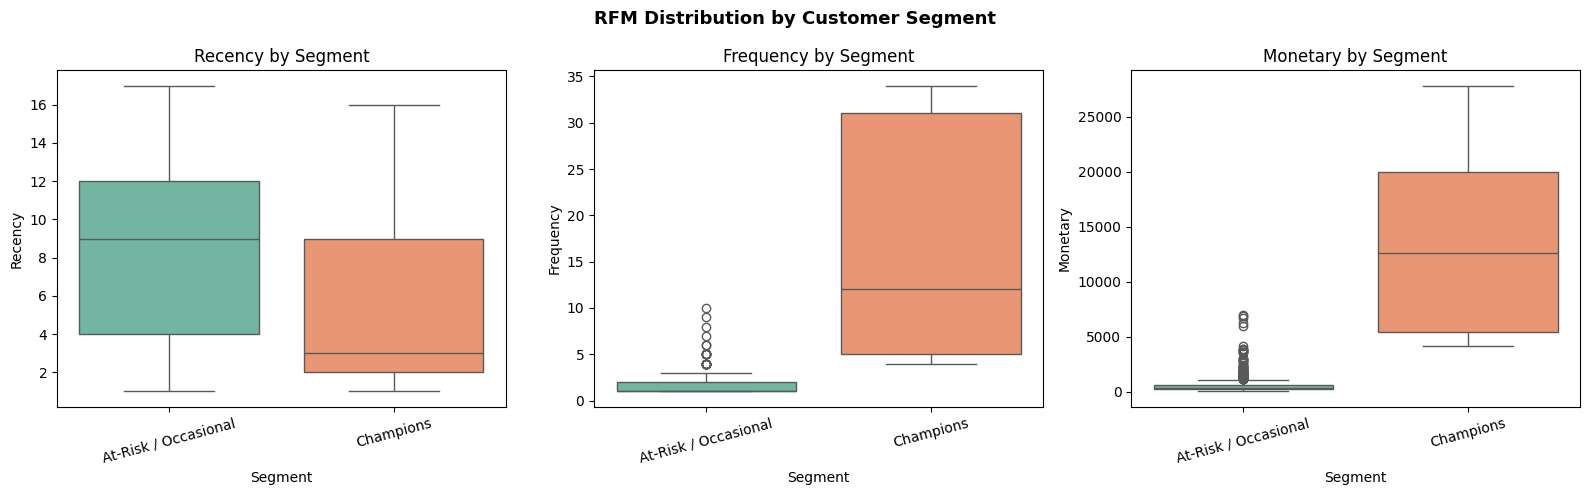

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.boxplot(data=rfm, x='Segment', y=col, palette='Set2', ax=ax)
    ax.set_title(f'{col} by Segment')
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('RFM Distribution by Customer Segment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_by_segment.png', dpi=150)
plt.show()

In [29]:
from mpl_toolkits.mplot3d import Axes3D


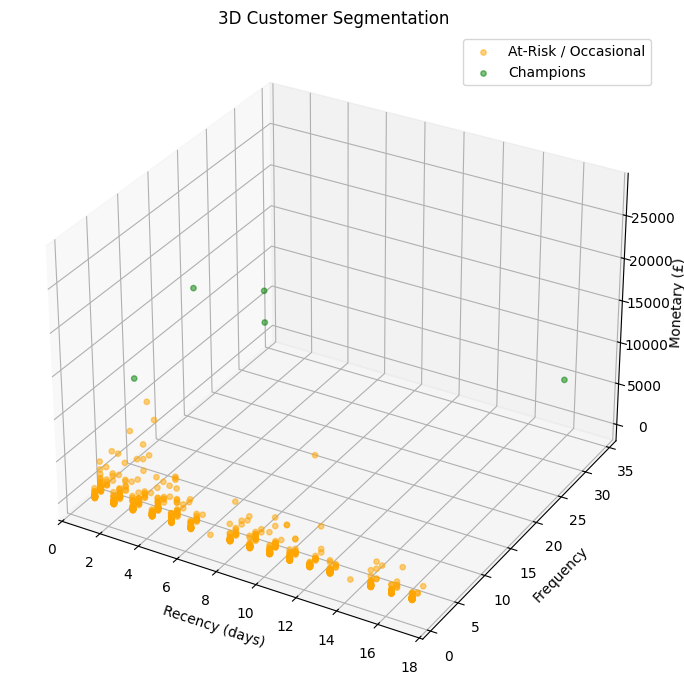

In [30]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
seg_colors = {'Champions': 'green', 'Loyal Customers': 'blue',
              'At-Risk / Occasional': 'orange', 'Lost Customers': 'red'}
for seg, grp in rfm.groupby('Segment'):
    ax.scatter(grp['Recency'], grp['Frequency'], grp['Monetary'],
               label=seg, alpha=0.5, s=15, color=seg_colors.get(seg, 'gray'))
ax.set_xlabel('Recency (days)')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary (£)')
ax.set_title('3D Customer Segmentation')
ax.legend()
plt.tight_layout()
plt.savefig('3d_segments.png', dpi=150)
plt.show()


In [31]:
seg_heatmap = cluster_profile[['Recency', 'Frequency', 'Monetary']].copy()
seg_heatmap.index = cluster_profile['Segment_Label']
seg_heatmap_norm = (seg_heatmap - seg_heatmap.min()) / (seg_heatmap.max() - seg_heatmap.min())


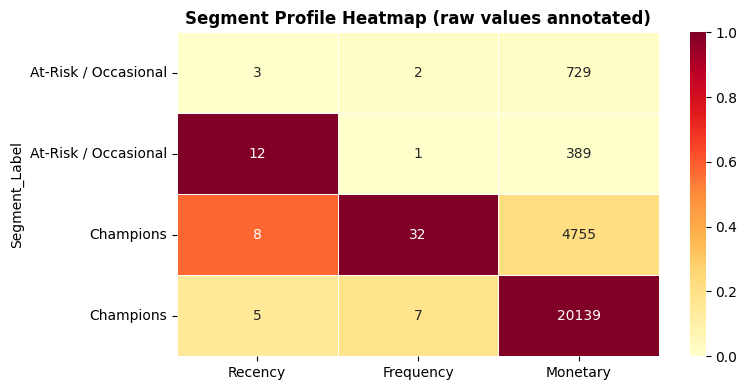

In [32]:
plt.figure(figsize=(8, 4))
sns.heatmap(seg_heatmap_norm, annot=seg_heatmap.values, fmt='.0f',
            cmap='YlOrRd', linewidths=0.5)
plt.title('Segment Profile Heatmap (raw values annotated)', fontweight='bold')
plt.tight_layout()
plt.savefig('segment_heatmap.png', dpi=150)
plt.show()

In [33]:
rfm_with_seg = rfm[['CustomerID', 'Segment']]
df_merged = df.merge(rfm_with_seg, on='CustomerID', how='left')


In [34]:
print("\n Top 5 Products per Segment:")
for seg in rfm['Segment'].unique():
    seg_data = df_merged[df_merged['Segment'] == seg]
    top_products = (seg_data.groupby('Description')['Quantity']
                    .sum()
                    .sort_values(ascending=False)
                    .head(5))
    print(f"\n  [{seg}]")
    print(top_products.to_string())


 Top 5 Products per Segment:

  [At-Risk / Occasional]
Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     4896
WHITE HANGING HEART T-LIGHT HOLDER    3257
HAND WARMER BABUSHKA DESIGN           2967
MINI PAINT SET VINTAGE                2376
RED  HARMONICA IN BOX                 2151

  [Champions]
Description
GROW A FLYTRAP OR SUNFLOWER IN TIN     2400
BLACK HEART CARD HOLDER                2016
CREAM HEART CARD HOLDER                2016
ROTATING SILVER ANGELS T-LIGHT HLDR    1204
WOOD BLACK BOARD ANT WHITE FINISH      1056


In [35]:
country_seg = (df_merged.groupby(['Segment', 'Country'])['CustomerID']
               .nunique()
               .reset_index()
               .rename(columns={'CustomerID': 'Customers'}))

In [36]:
print("\n Top Countries per Segment:")
for seg in rfm['Segment'].unique():
    top_countries = country_seg[country_seg['Segment'] == seg].nlargest(3, 'Customers')
    print(f"\n  [{seg}]")
    print(top_countries[['Country', 'Customers']].to_string(index=False))


 Top Countries per Segment:

  [At-Risk / Occasional]
       Country  Customers
United Kingdom        773
       Germany         15
        France         12

  [Champions]
       Country  Customers
United Kingdom          5


In [37]:
with open("customer_segmentation_kmeans.pkl", "wb") as f:
    pickle.dump({'kmeans': kmeans, 'scaler': scaler, 'label_map': label_map}, f)


In [38]:
rfm.to_csv("customer_segments.csv", index=False)

print("\n KMeans model saved: customer_segmentation_kmeans.pkl")
print(" Segments CSV saved: customer_segments.csv")


 KMeans model saved: customer_segmentation_kmeans.pkl
 Segments CSV saved: customer_segments.csv


In [39]:
print("\n" + "="*60)
print("KEY BUSINESS INSIGHTS — ONLINE RETAIL")
print("="*60)


KEY BUSINESS INSIGHTS — ONLINE RETAIL


In [40]:
for seg in rfm['Segment'].unique():
    seg_data = rfm[rfm['Segment'] == seg]
    pct = len(seg_data) / len(rfm) * 100
    print(f"\n🔹 {seg} ({pct:.1f}% of customers)")
    print(f"   Avg Recency:   {seg_data['Recency'].mean():.0f} days")
    print(f"   Avg Frequency: {seg_data['Frequency'].mean():.1f} orders")
    print(f"   Avg Monetary:  £{seg_data['Monetary'].mean():,.0f}")



🔹 At-Risk / Occasional (99.4% of customers)
   Avg Recency:   8 days
   Avg Frequency: 1.4 orders
   Avg Monetary:  £540

🔹 Champions (0.6% of customers)
   Avg Recency:   6 days
   Avg Frequency: 17.2 orders
   Avg Monetary:  £13,986


In [41]:
print("\n Recommendations:")
print("  Champions     → Reward with loyalty programs, early access to new products")
print("  Loyal         → Upsell/cross-sell, offer membership tiers")
print("  At-Risk       → Win-back campaigns, discount vouchers")
print("  Lost          → Re-engagement emails, 'We miss you' promotions")


 Recommendations:
  Champions     → Reward with loyalty programs, early access to new products
  Loyal         → Upsell/cross-sell, offer membership tiers
  At-Risk       → Win-back campaigns, discount vouchers
  Lost          → Re-engagement emails, 'We miss you' promotions
